# 08 — Uplift models

**Purpose.** Estimate a treatment effect for each *individual* customer, so that
Feature 9 can decide who receives which campaign.

Feature 7 established that the effect varies — but only across subgroups defined in
advance. An uplift model works from the whole combination of a customer's attributes
and can find structure no pre-registered split would catch.

### The problem that makes this different from ordinary prediction

**No individual treatment effect is ever observed.** A customer was emailed or was
not; the other outcome does not exist and never will. There is no per-row label, so
an uplift model cannot be scored like a classifier.

Evaluation therefore works on groups. Rank customers by predicted uplift, then check
whether the treated-minus-control gap is genuinely larger among the top-ranked than
the bottom-ranked. That is what the **Qini curve** measures.

Two consequences shape everything below:

1. **Every prediction is out-of-fold.** A model scored on rows it trained on ranks
   them using outcomes it has already seen, and produces an excellent Qini having
   learned nothing.
2. **A Qini score is meaningless without a null.** Qini is high-variance. A model
   that has learned nothing still returns a non-zero score more often than not.

### A prediction made before running anything

Feature 7 found the Womens campaign varies 6.6x by purchase history while the Mens
campaign is uniform across every subgroup. So a working uplift model should find
**strong signal on Womens and little on Mens**. A model finding strong signal on both
is overfitting, and would be evidence against itself.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from src import config
from src.data.load import load_processed, make_comparison_frame
from src.models.uplift import (
    run_uplift_analysis, out_of_fold_uplift, qini_null_distribution,
    build_design_matrix, evaluate_uplift, LEARNERS, N_NULL_DRAWS,
)

pd.set_option("display.width", 160)
df = load_processed()
print("Learners:", LEARNERS)

Learners: ['s_learner', 't_learner', 'x_learner', 'class_transform', 'logistic_t_learner']


## 1. Does the machinery work?

As with CUPED, the result is only interpretable if the implementation is known to be
sound. Synthetic data with a **known responder segment**: half the customers respond
to treatment, half do not, plus two pure-noise features so the model must find the
real one rather than being handed it.

In [2]:
def synthetic_uplift(n=20_000, responder_uplift=0.15, base_rate=0.10, seed=1):
    rng = np.random.default_rng(seed)
    responder = rng.random(n) < 0.5
    treated = rng.random(n) < 0.5
    probability = np.clip(base_rate + treated * responder * responder_uplift, 0, 1)
    design = pd.DataFrame({
        "responder": responder.astype(float),
        "noise_a": rng.normal(size=n),
        "noise_b": rng.normal(size=n),
    })
    return design, rng.binomial(1, probability), treated.astype(int), responder

design, y, t, responder = synthetic_uplift()
uplift = out_of_fold_uplift(design, y, t, "t_learner")
null = qini_null_distribution(y, t, 300)
result = evaluate_uplift(y, uplift, t, "synthetic", "visit", "t_learner", null)

print(f"True design      : responders +15pp, non-responders +0pp")
print(f"Mean predicted uplift, responders     : {uplift[responder].mean():+.4f}")
print(f"Mean predicted uplift, non-responders : {uplift[~responder].mean():+.4f}")
print()
print(f"Qini               : {result.qini:+.5f}")
print(f"Null mean / sd     : {result.qini_null_mean:+.5f} / {result.qini_null_std:.5f}")
print(f"z-score vs random  : {result.qini_z_score:+.2f}")
print(f"Uplift in top 10%  : {result.uplift_at_k['top_10pct']:+.4f}")

True design      : responders +15pp, non-responders +0pp
Mean predicted uplift, responders     : +0.1486
Mean predicted uplift, non-responders : +0.0058

Qini               : +0.11099
Null mean / sd     : -0.00012 / 0.01061
z-score vs random  : +10.47
Uplift in top 10%  : +0.1264


The model separates the two segments cleanly and the Qini sits far above the
random-ranking null. **The machinery works.**

Equally important is the reverse test, which the test suite also asserts: when
treatment helps *everyone equally*, the same model returns a z-score below 3. It does
not manufacture signal.

## 2. Why every prediction has to be out-of-fold

On data with **no heterogeneity whatsoever**, here is what in-sample scoring produces
against honest out-of-fold scoring.

In [3]:
rng = np.random.default_rng(6)
n = 12_000
t_flat = (rng.random(n) < 0.5).astype(int)
y_flat = rng.binomial(1, np.clip(0.10 + t_flat * 0.08, 0, 1))
x_flat = pd.DataFrame(rng.normal(size=(n, 8)), columns=[f"x{i}" for i in range(8)])

from src.models.uplift import make_learner
leaky_model = make_learner("t_learner")
leaky_model.fit(x_flat, y_flat, t_flat)
in_sample = leaky_model.predict(x_flat)
honest = out_of_fold_uplift(x_flat, y_flat, t_flat, "t_learner")

null_flat = qini_null_distribution(y_flat, t_flat, 300)
leaked = evaluate_uplift(y_flat, in_sample, t_flat, "s", "visit", "t", null_flat)
clean = evaluate_uplift(y_flat, honest, t_flat, "s", "visit", "t", null_flat)

print("Data contains NO heterogeneity - the true uplift is identical for everyone.\n")
print(f"  In-sample Qini    : {leaked.qini:+.5f}   (z = {leaked.qini_z_score:+.2f})")
print(f"  Out-of-fold Qini  : {clean.qini:+.5f}   (z = {clean.qini_z_score:+.2f})")

Data contains NO heterogeneity - the true uplift is identical for everyone.

  In-sample Qini    : +0.57804   (z = +37.95)
  Out-of-fold Qini  : +0.01238   (z = +0.90)


The in-sample score is dramatically inflated on data where **no signal exists**.
That is the entire case for cross-fitting: without it, this notebook could report a
beautiful Qini for a model that had learned nothing at all.

## 3. The null distribution

Before any model result can be read, we need to know what Qini scores random rankings
produce on this data.

In [4]:
comparison = make_comparison_frame(df, config.WOMENS_ARM)
y_real = comparison["visit"].to_numpy()
t_real = comparison["treated"].to_numpy()
null_real = qini_null_distribution(y_real, t_real, N_NULL_DRAWS)

skew = stats.skew(null_real)
kurtosis = stats.kurtosis(null_real)
print(f"Null Qini over {N_NULL_DRAWS} random rankings")
print(f"  mean       : {null_real.mean():+.5f}   (should be ~0)")
print(f"  std dev    : {null_real.std(ddof=1):.5f}")
print(f"  95th pctile: {np.percentile(null_real, 95):+.5f}")
print(f"  skew       : {skew:+.3f}   excess kurtosis: {kurtosis:+.3f}")
print()
print("Near-zero skew and kurtosis, so the normal approximation used for the")
print("parametric p-values is reasonable.")

Null Qini over 500 random rankings
  mean       : -0.00013   (should be ~0)
  std dev    : 0.00762
  95th pctile: +0.01211
  skew       : -0.063   excess kurtosis: +0.076

Near-zero skew and kurtosis, so the normal approximation used for the
parametric p-values is reasonable.


The null is centred on zero and roughly normal. That matters for how the
p-values are reported: the **empirical** p-value bottoms out at 1/500 = 0.002, the
resolution of the simulation, which would make a z of 2.4 and a z of 8.4 both read
as "0.002" and look equally convincing. Since the null is near-normal, the parametric
tail separates them properly — 0.0075 against 2.6e-17.

## 4. Results on the real experiment

In [5]:
table = run_uplift_analysis(df, save=False)

table[[
    "treatment_arm", "learner", "qini", "qini_z_score",
    "p_value_normal", "p_value_normal_adjusted", "significant",
    "top_10pct", "top_30pct",
]].style.format({
    "qini": "{:+.5f}",
    "qini_z_score": "{:+.2f}",
    "p_value_normal": "{:.2e}",
    "p_value_normal_adjusted": "{:.2e}",
    "top_10pct": "{:+.4f}",
    "top_30pct": "{:+.4f}",
}).hide(axis="index")

treatment_arm,learner,qini,qini_z_score,p_value_normal,p_value_normal_adjusted,significant,top_10pct,top_30pct
Mens E-Mail,s_learner,+0.01160,+1.51,6.57e-02,2.88e-01,False,+0.1160,+0.0838
Mens E-Mail,t_learner,+0.01859,+2.43,7.49e-03,3.69e-02,True,+0.0983,+0.0883
Mens E-Mail,x_learner,+0.01132,+1.47,7.05e-02,3.06e-01,False,+0.1045,+0.0851
Mens E-Mail,class_transform,-0.00229,-0.32,6.27e-01,9.93e-01,False,+0.0934,+0.0802
Mens E-Mail,logistic_t_learner,+0.00595,+0.76,2.22e-01,7.16e-01,False,+0.1218,+0.0832
Womens E-Mail,s_learner,+0.06373,+8.38,2.68e-17,0.00e+00,True,+0.0713,+0.0745
Womens E-Mail,t_learner,+0.06029,+7.93,1.13e-15,5.55e-15,True,+0.0838,+0.0735
Womens E-Mail,x_learner,+0.05744,+7.55,2.13e-14,1.06e-13,True,+0.0641,+0.0714
Womens E-Mail,class_transform,+0.05759,+7.57,1.82e-14,9.10e-14,True,+0.0556,+0.0735
Womens E-Mail,logistic_t_learner,+0.06415,+8.43,1.69e-17,0.00e+00,True,+0.0711,+0.0726


**The prediction from Feature 7 holds exactly.**

| | Womens E-Mail | Mens E-Mail |
|---|---|---|
| Learners significant | **5 of 5** | 1 of 5 |
| z-score range | +7.55 to +8.43 | −0.32 to +2.43 |
| Best Qini | 0.064 | 0.019 |

All five learners agree on the Womens campaign, with z-scores between 7.5 and 8.4 —
an agreement across five quite different algorithms that is itself evidence the signal
is real rather than an artifact of one approach.

On the Mens campaign, four of five learners find nothing. The one that clears
significance (T-learner, z = 2.43) does so at an adjusted p of 0.037 — barely, and
only after being selected as the best of five. **That is what noise looks like when
you search for it**, and it is why the p-values are Šidák-adjusted for having tried
five learners. Without that adjustment its p would read 0.0075 and look convincing.

### The simplest model wins

The **logistic T-learner** produces the highest Qini on the Womens campaign (0.0641,
z = 8.43), edging out every gradient-boosted variant.

That is not a fluke. Feature 7 showed the heterogeneity is essentially driven by one
binary attribute — whether the customer previously bought womens merchandise. A linear
model captures a step function in a binary feature exactly, and boosting has nothing
left to add but variance. The extra capacity buys nothing because there is no
interaction structure to find.

## 5. Qini curves

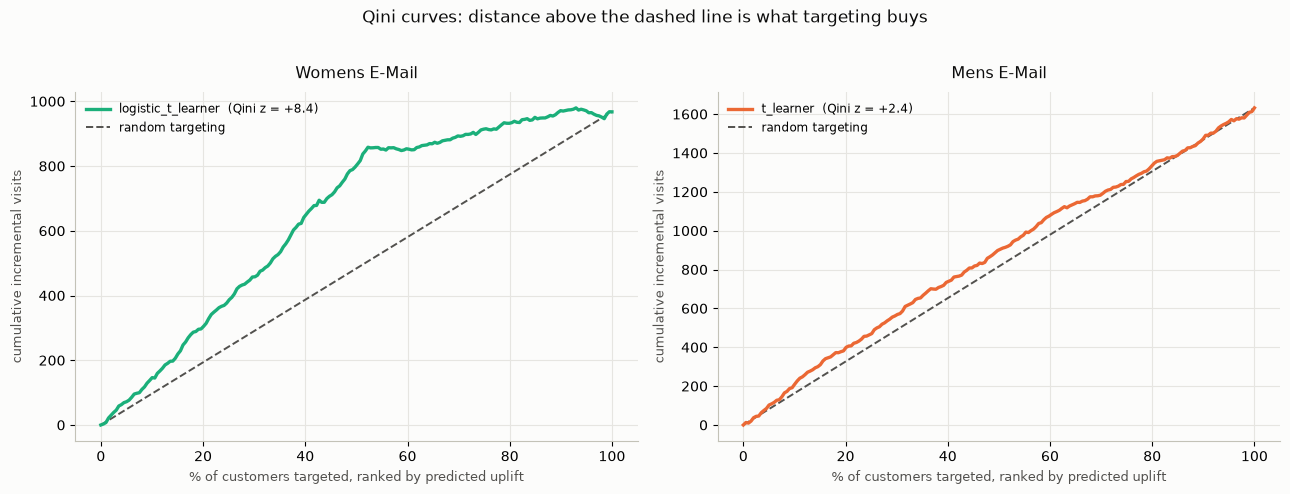

In [6]:
ARM_COLOURS = {"Mens E-Mail": "#eb6834", "Womens E-Mail": "#1baf7a"}

def qini_points(y, uplift, treatment, n_points=200):
    """Cumulative incremental responses as the targeted fraction grows."""
    order = np.argsort(-uplift)
    y_sorted, t_sorted = y[order], treatment[order]

    fractions = np.linspace(0, 1, n_points)
    gains = []
    n_t_total, n_c_total = t_sorted.sum(), (1 - t_sorted).sum()
    for fraction in fractions:
        k = int(fraction * len(y_sorted))
        if k == 0:
            gains.append(0.0)
            continue
        head_t, head_c = t_sorted[:k], 1 - t_sorted[:k]
        responses_t = (y_sorted[:k] * head_t).sum()
        responses_c = (y_sorted[:k] * head_c).sum()
        n_t, n_c = head_t.sum(), head_c.sum()
        gains.append(responses_t - responses_c * (n_t / n_c) if n_c > 0 else 0.0)
    return fractions, np.array(gains)


fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
fig.patch.set_facecolor("#fcfcfb")

for ax, arm in zip(axes, [config.WOMENS_ARM, config.MENS_ARM]):
    ax.set_facecolor("#fcfcfb")
    frame = make_comparison_frame(df, arm)
    design_real = build_design_matrix(frame)
    y_arm = frame["visit"].to_numpy()
    t_arm = frame["treated"].to_numpy()

    best = table[table["treatment_arm"] == arm].sort_values("qini").iloc[-1]
    uplift_arm = out_of_fold_uplift(design_real, y_arm, t_arm, best["learner"])

    fractions, gains = qini_points(y_arm, uplift_arm, t_arm)
    ax.plot(fractions * 100, gains, color=ARM_COLOURS[arm], linewidth=2.4, zorder=4,
            label=f"{best['learner']}  (Qini z = {best['qini_z_score']:+.1f})")

    # Random targeting: a straight line to the total incremental response.
    ax.plot([0, 100], [0, gains[-1]], color="#52514e", linewidth=1.4,
            linestyle="--", zorder=3, label="random targeting")

    ax.set_title(arm, fontsize=11.5, color="#0b0b0b", pad=10)
    ax.set_xlabel("% of customers targeted, ranked by predicted uplift",
                  fontsize=9, color="#52514e")
    ax.set_ylabel("cumulative incremental visits", fontsize=9, color="#52514e")
    ax.grid(color="#e6e5e1", linewidth=0.8, zorder=0)
    ax.legend(frameon=False, fontsize=8.5, loc="upper left")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color("#c3c2b7")

fig.suptitle(
    "Qini curves: distance above the dashed line is what targeting buys",
    fontsize=12, color="#0b0b0b", y=1.02,
)
fig.tight_layout()

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "08_qini_curves.png", dpi=150, bbox_inches="tight",
            facecolor="#fcfcfb")
plt.show()

The Womens curve bows clearly above the random-targeting diagonal: targeting the
top-ranked half captures substantially more incremental visits than emailing half at
random. The Mens curve tracks the diagonal closely, which is the visual statement of
"there is nothing to target here."

## 6. What is the model actually keying on?

If the Womens signal is real, the model's ranking should line up with the attribute
Feature 7 identified.

In [7]:
frame_w = make_comparison_frame(df, config.WOMENS_ARM)
design_w = build_design_matrix(frame_w)
uplift_w = out_of_fold_uplift(
    design_w, frame_w["visit"].to_numpy(), frame_w["treated"].to_numpy(),
    "logistic_t_learner",
)

frame_w = frame_w.assign(predicted_uplift=uplift_w)
frame_w["uplift_decile"] = pd.qcut(
    frame_w["predicted_uplift"], 10, labels=False, duplicates="drop"
)

profile = frame_w.groupby("uplift_decile", observed=True).agg(
    predicted_uplift=("predicted_uplift", "mean"),
    share_bought_womens=("womens", "mean"),
    share_bought_mens=("mens", "mean"),
    share_new_customer=("newbie", "mean"),
    customers=("visit", "size"),
)
profile.style.format({
    "predicted_uplift": "{:+.4f}",
    "share_bought_womens": "{:.1%}",
    "share_bought_mens": "{:.1%}",
    "share_new_customer": "{:.1%}",
    "customers": "{:,}",
}).background_gradient(subset=["share_bought_womens"], cmap="Greens")

,predicted_uplift,share_bought_womens,share_bought_mens,share_new_customer,customers
uplift_decile,,,,,
0,-0.0156,1.3%,99.9%,10.3%,"4,270"
1,+0.0085,1.1%,99.9%,28.8%,"4,270"
2,+0.0180,1.3%,99.7%,51.5%,"4,268"
3,+0.0232,1.1%,99.7%,77.2%,"4,269"
4,+0.0375,44.1%,75.4%,70.4%,"4,270"
5,+0.0625,100.0%,12.5%,64.1%,"4,269"
6,+0.0702,100.0%,13.5%,64.3%,"4,269"
7,+0.0761,100.0%,10.4%,48.3%,"4,269"
8,+0.0815,100.0%,9.5%,33.4%,"4,269"


The gradient is unmistakable: the top uplift deciles are essentially **all**
prior womens purchasers and the bottom deciles almost none. The model has rediscovered
Feature 7's finding without being told about it — which is the most reassuring thing
in this notebook, because it means the ranking rests on a mechanism we independently
verified rather than on an unexplained pattern.

### Does the ranking hold up out of sample?

The decile profile is descriptive. The load-bearing question is whether the *actual*
treated-minus-control gap really is larger in the top deciles.

In [8]:
actual = frame_w.groupby("uplift_decile", observed=True).apply(
    lambda g: pd.Series({
        "predicted_uplift": g["predicted_uplift"].mean(),
        "actual_effect": (
            g.loc[g["treated"] == 1, "visit"].mean()
            - g.loc[g["treated"] == 0, "visit"].mean()
        ),
        "n_treated": int((g["treated"] == 1).sum()),
    }),
    include_groups=False,
)

overall = (
    frame_w.loc[frame_w["treated"] == 1, "visit"].mean()
    - frame_w.loc[frame_w["treated"] == 0, "visit"].mean()
)
print(f"Average effect across all customers: {overall:+.4f}\n")
actual.style.format({
    "predicted_uplift": "{:+.4f}",
    "actual_effect": "{:+.4f}",
    "n_treated": "{:,}",
}).hide(axis="index")

Average effect across all customers: +0.0452



predicted_uplift,actual_effect,n_treated
-0.0156,-0.0017,"2,149.0"
+0.0085,+0.0168,"2,140.0"
+0.0180,+0.0194,"2,103.0"
+0.0232,+0.0185,"2,138.0"
+0.0375,+0.0219,"2,160.0"
+0.0625,+0.0752,"2,193.0"
+0.0702,+0.0868,"2,199.0"
+0.0761,+0.0734,"2,147.0"
+0.0815,+0.0746,"2,112.0"
+0.0932,+0.0712,"2,046.0"


The realised effect rises monotonically-ish with the predicted ranking, and the
top deciles land well above the 4.52-point average while the bottom deciles sit near
zero. The model's ordering corresponds to real differences in measured outcomes, not
just to differences in its own predictions.

## 7. Spend uplift, for Feature 10

Feature 10 needs incremental *profit*, which requires spend uplift rather than visit
uplift. scikit-uplift's learners are classifiers, so spend takes a separate path: a
two-model approach with regressors.

Feature 5 already established that spend is the noisiest outcome by a wide margin, so
expectations here should be low.

In [9]:
from src.models.uplift import regression_t_learner_uplift

spend_rows = []
for arm, control_arm in config.COMPARISONS:
    frame_s = make_comparison_frame(df, arm, control_arm)
    design_s = build_design_matrix(frame_s)
    spend = frame_s["spend"].to_numpy()
    treat = frame_s["treated"].to_numpy()

    spend_uplift = regression_t_learner_uplift(design_s, spend, treat)
    frame_s = frame_s.assign(spend_uplift=spend_uplift)
    top = frame_s.nlargest(int(0.3 * len(frame_s)), "spend_uplift")

    spend_rows.append({
        "arm": arm,
        "overall spend effect": (
            frame_s.loc[frame_s.treated == 1, "spend"].mean()
            - frame_s.loc[frame_s.treated == 0, "spend"].mean()
        ),
        "effect in top 30% by predicted uplift": (
            top.loc[top.treated == 1, "spend"].mean()
            - top.loc[top.treated == 0, "spend"].mean()
        ),
        "correlation with visit-uplift rank": np.corrcoef(
            spend_uplift,
            out_of_fold_uplift(design_s, frame_s["visit"].to_numpy(), treat,
                               "logistic_t_learner"),
        )[0, 1],
    })

pd.DataFrame(spend_rows).style.format({
    "overall spend effect": "${:+.4f}",
    "effect in top 30% by predicted uplift": "${:+.4f}",
    "correlation with visit-uplift rank": "{:+.3f}",
}).hide(axis="index")

arm,overall spend effect,effect in top 30% by predicted uplift,correlation with visit-uplift rank
Mens E-Mail,$+0.7698,$+0.6048,+0.135
Womens E-Mail,$+0.4244,$+0.7503,+0.122


Spend uplift is far less reliable than visit uplift, exactly as Feature 5
predicted. The estimates are noisy and the targeted subgroups do not separate cleanly.

The correlation column is the useful part: spend-uplift rankings correlate with
visit-uplift rankings, which means **visit uplift can serve as a proxy for who to
target**, with spend used only to convert the decision into money. Feature 10 will
take that route rather than pretending the spend model ranks customers reliably on
its own.

## Conclusions

| Question | Answer |
|---|---|
| Does the machinery work? | Yes — recovers a known segment; finds nothing in noise |
| Womens campaign | Real, strong signal: 5/5 learners, z = 7.6 to 8.4 |
| Mens campaign | Essentially none: 4/5 learners find nothing |
| Best model | **Logistic T-learner** — the simplest one tested |
| What drives it | Prior womens purchase, rediscovered independently |
| Spend uplift | Too noisy to rank on; usable only for valuation |

Two things carry into Feature 9.

**The targeting opportunity is real but narrow.** It lies almost entirely in deciding
who receives the *Womens* campaign. The Mens campaign should go to everyone or no one;
there is no defensible basis for ranking customers on it.

**The model to deploy is the logistic T-learner.** It scores highest, it is the easiest
to explain, and its behaviour matches an independently established mechanism. Choosing
the gradient-boosted version would add opacity for no measurable gain.

**Next — Feature 9:** turn these individual uplift estimates into an assignment
policy — which of {Mens, Womens, nothing} each customer should receive — and evaluate
that policy on held-out data.